In [42]:
import os
from pathlib import Path
import json
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

with open('/SSD_DISK/users/yangzeyu/gaussian-splatting-4d/data/N3V/cut_roasted_beef/transforms_test.json') as fp:
    contents = fp.read()
meta = json.loads(contents)
frames = meta['frames']

In [43]:
cam_centers = []
z_dirs = []
c2ws = []

for frame in frames:
    if int(frame['file_path'].split('_')[-1]) != 0:
        continue
    c2w = np.array(frame["transform_matrix"])
    # change from OpenGL/Blender camera axes (Y up, Z back) to COLMAP (Y down, Z forward)
    c2w[:3, 1:3] *= -1

    # get the world-to-camera transform and set R, T
    w2c = np.linalg.inv(c2w)
    R = np.transpose(w2c[:3,:3])  # R is stored transposed due to 'glm' in CUDA code
    t = w2c[:3, 3]

    Rt = np.zeros((4, 4))
    Rt[:3, :3] = R.transpose()
    Rt[:3, 3] = t
    Rt[3, 3] = 1.0

    C2W = np.linalg.inv(Rt)
    cam_center = C2W[:3, 3]
    C2W[:3, 3] = cam_center
    Rt = np.linalg.inv(C2W)
    z_dir = C2W[:3, 2]
    
    c2ws.append(C2W)
    cam_centers.append(cam_center)
    z_dirs.append(z_dir)

In [34]:
anchor_point = np.array([-3.163622, -0.688396, -0.043378])
cam_centers = np.concatenate([cam_centers], axis=0)

/home/yangzeyu/anaconda3/envs/open-mmlab/lib/python3.7/site-packages/ipykernel_launcher.py:8: MatplotlibDeprecationWarning: Axes3D(fig) adding itself to the figure is deprecated since 3.4. Pass the keyword argument auto_add_to_figure=False and use fig.add_axes(ax) to suppress this warning. The default value of auto_add_to_figure will change to False in mpl3.5 and True values will no longer work in 3.6.  This is consistent with other Axes classes.
  


Text(0.5, 0, 'X')

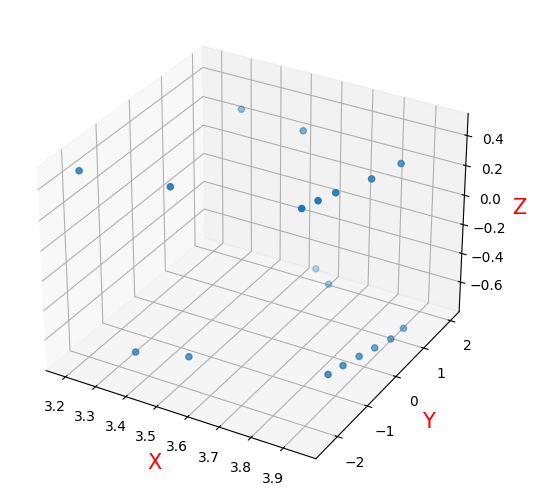

In [38]:

x = cam_centers[:, 0]  # [ 0  3  6  9 12 15 18 21]
y = cam_centers[:, 1]  # [ 1  4  7 10 13 16 19 22]
z = cam_centers[:, 2]  # [ 2  5  8 11 14 17 20 23]
 
 
# 绘制散点图
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(x, y, z)
 
 
# 添加坐标轴(顺序是Z, Y, X)
ax.set_zlabel('Z', fontdict={'size': 15, 'color': 'red'})
ax.set_ylabel('Y', fontdict={'size': 15, 'color': 'red'})
ax.set_xlabel('X', fontdict={'size': 15, 'color': 'red'})


In [39]:
x.mean()
# y -1 1
# z -0.2 -0.0

3.710463052910638

In [102]:
num_steps = 300

T = 2
w = 2 * np.pi / T
A = 0.1
sample_y = np.linspace(-1,1,num_steps)
sample_z = A * np.cos(w*sample_y) - 0.1
sample_x = np.zeros_like(sample_y) + 3.71
sample_points = np.stack([sample_x,sample_y,sample_z], 1)

sample_points.min(axis=0)
z_dir = anchor_point - sample_points
sample_z_dir = z_dir / np.linalg.norm(z_dir, axis=1, keepdims=True)

In [105]:
sample_y_dir = np.array([[0.,0.,1.]]) - sample_z_dir[:,2:3] * sample_z_dir 
sample_z_dir = -sample_z_dir
sample_x_dir = np.cross(sample_y_dir, sample_z_dir) # X right, Y up, Z back

In [106]:
sample_x_dir.shape

(300, 3)

In [107]:
frames = []
for i in range(num_steps):
    frame = {'file_path': 'images/cam00_0000'}
    c2w = np.zeros((4, 4))
    c2w[3,3] = 1
    c2w[:3, 0] = sample_x_dir[i]
    c2w[:3, 1] = sample_y_dir[i]
    c2w[:3, 2] = sample_z_dir[i]
    c2w[:3, 3] = sample_points[i]
    frame['transform_matrix'] = c2w.tolist()
    frame['time'] = i / 30
    frames.append(frame)

In [108]:
meta['frames'] = frames
with open('/SSD_DISK/users/yangzeyu/gaussian-splatting-4d/data/N3V/cut_roasted_beef/transforms_test.json', 'w') as out_file:
    json.dump(meta, out_file, indent=4)

In [109]:
num_steps

300

In [97]:
sample_points[:,1].min()

-1.0

In [100]:
[np.array(frame['transform_matrix'][2,3]) for frame in frames]

array([[-0.23848474,  0.02147885,  0.97089423,  3.71      ],
       [ 0.97089423,  0.00527594,  0.23848474,  1.        ],
       [ 0.        ,  0.99951058, -0.02212275, -0.2       ],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])